# Online Payment Fraud Detection

## Project Overview

This project uses machine learning to identify potentially fraudulent
online payment transactions.

The main objective is to build a classification model that can distinguish
between fraudulent and legitimate transactions while focusing on metrics
such as Precision, Recall, F1-score and PR-AUC.

### Machine Learning Workflow

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Model Training
- Model Comparison
- Model Evaluation
- Fraud Prediction

### Models Used

- Decision Tree
- Random Forest

**1.IMPORT LIBRARIES**


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

 **2. LOAD DATA**

In [23]:
DATA_PATH = "PS_20174392719_1491204439457_log 3.csv"

data = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATA LOADED SUCCESSFULLY")
print("=" * 70)

print("Shape:", data.shape)

print("\nFirst 5 rows:")
display(data.head())

DATA LOADED SUCCESSFULLY
Shape: (1048575, 11)

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**3. DATA INFORMATION**

In [24]:
print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

# Remove duplicates
data = data.drop_duplicates().reset_index(drop=True)

print("\nDataset Shape After Removing Duplicates:")
print(data.shape)


DATA QUALITY CHECK

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate Rows:
0

Dataset Shape After Removing Duplicates:
(1048575, 11)


**3. FRAUD DISTRIBUTION**


FRAUD DISTRIBUTION
isFraud
0    1047433
1       1142
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.8911
1     0.1089
Name: proportion, dtype: float64


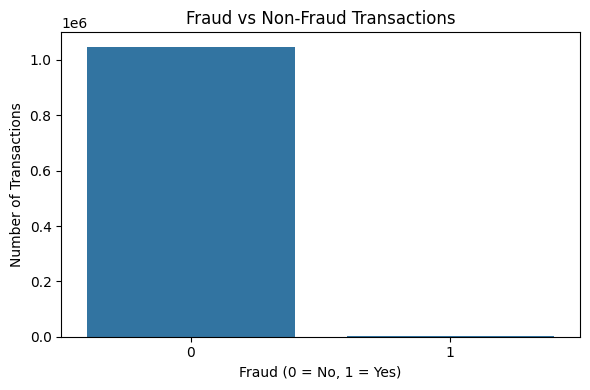

In [25]:
print("\n" + "=" * 60)
print("FRAUD DISTRIBUTION")
print("=" * 60)

fraud_counts = data["isFraud"].value_counts()

print(fraud_counts)

print("\nFraud Percentage:")

fraud_percentage = (
    data["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
)

print(fraud_percentage.round(4))


# Visualization

plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="isFraud"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

**FRAUD BY TRANSACTION AMOUNT**

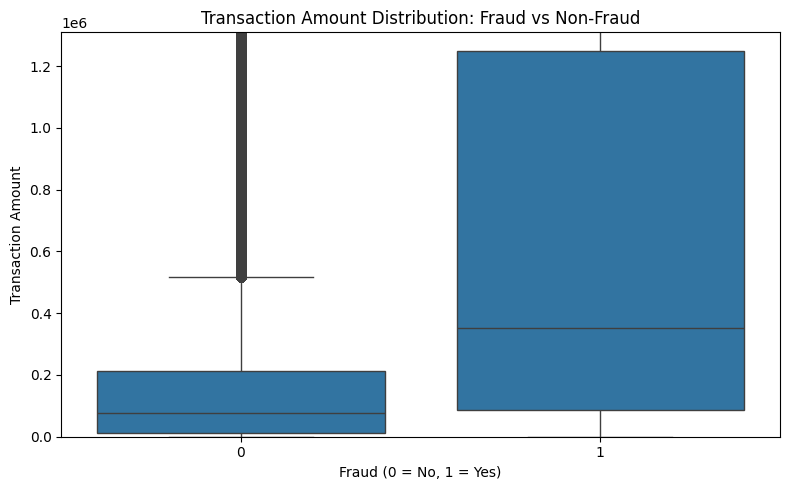

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="isFraud",
    y="amount"
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")

plt.ylim(
    0,
    data["amount"].quantile(0.99)
)

plt.tight_layout()
plt.show()

**4. TRANSACTION TYPE ANALYSIS**


TRANSACTION TYPE ANALYSIS
type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

Fraud Rate by Transaction Type:
type
TRANSFER    0.650
CASH_OUT    0.155
CASH_IN     0.000
DEBIT       0.000
PAYMENT     0.000
Name: isFraud, dtype: float64


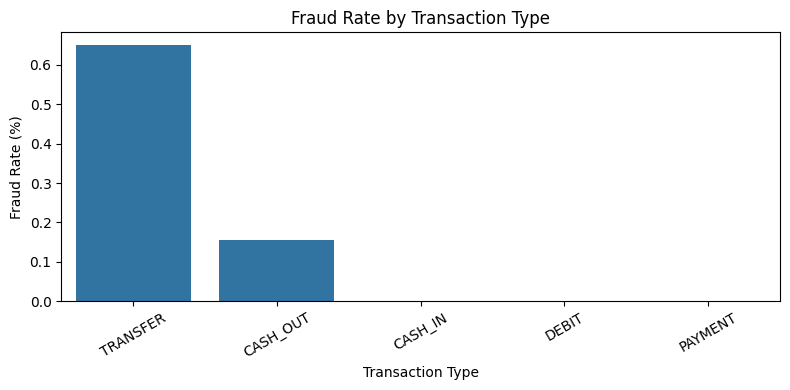

In [26]:
print("\n" + "=" * 60)
print("TRANSACTION TYPE ANALYSIS")
print("=" * 60)

print(
    data["type"].value_counts()
)


fraud_rate = (
    data.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nFraud Rate by Transaction Type:")
print(fraud_rate.round(3))


plt.figure(figsize=(8, 4))

sns.barplot(
    x=fraud_rate.index,
    y=fraud_rate.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**5. FEATURE ENGINEERING**

In [27]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

df = data.copy()


# Origin account balance change
df["orig_balance_change"] = (
    df["oldbalanceOrg"] -
    df["newbalanceOrig"]
)


# Destination account balance change
df["dest_balance_change"] = (
    df["newbalanceDest"] -
    df["oldbalanceDest"]
)


# Difference between transaction amount
# and actual origin balance change
df["balance_error"] = (
    df["amount"] -
    df["orig_balance_change"]
).abs()

# Transaction amount relative to
# origin account balance
df["amount_balance_ratio"] = (
    df["amount"] /
    (df["oldbalanceOrg"] + 1)
)


# Check if account was completely drained
df["account_drained"] = (
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0)
).astype(int)


print("\nNew Features Created:")

print([
    "orig_balance_change",
    "dest_balance_change",
    "balance_error",
    "amount_balance_ratio",
    "account_drained"
])



FEATURE ENGINEERING

New Features Created:
['orig_balance_change', 'dest_balance_change', 'balance_error', 'amount_balance_ratio', 'account_drained']


**6. SELECT FEATURES**

In [28]:
features = [

    # Original features
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",

    # Engineered features
    "orig_balance_change",
    "dest_balance_change",
    "balance_error",
    "amount_balance_ratio",
    "account_drained"
]

X = df[features]

y = df["isFraud"]


print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Feature Shape:
(1048575, 13)

Target Shape:
(1048575,)


**7. TRAIN TEST SPLIT**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])



TRAIN TEST SPLIT
Training Records: 838860
Testing Records: 209715


**8. ENCODE TRANSACTION TYPE**

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "transaction_type",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            ["type"]
        )
    ],
    remainder="passthrough"
)


X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

**9. DECISION TREE MODEL**

In [31]:
print("\n" + "=" * 60)
print("DECISION TREE MODEL")
print("=" * 60)

decision_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)


decision_tree.fit(
    X_train_processed,
    y_train
)


dt_prediction = decision_tree.predict(
    X_test_processed
)

dt_probability = decision_tree.predict_proba(
    X_test_processed
)[:, 1]





DECISION TREE MODEL


**10. RANDOM FOREST MODEL**

In [32]:
print("\n" + "=" * 60)
print("RANDOM FOREST MODEL")
print("=" * 60)

random_forest = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


random_forest.fit(
    X_train_processed,
    y_train
)


rf_prediction = random_forest.predict(
    X_test_processed
)

rf_probability = random_forest.predict_proba(
    X_test_processed
)[:, 1]


RANDOM FOREST MODEL


**11. MODEL EVALUATION FUNCTION**

In [33]:
def evaluate_model(
    model_name,
    actual,
    prediction,
    probability
):

    precision = precision_score(
        actual,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        actual,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        actual,
        prediction,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        actual,
        probability
    )

    pr_auc = average_precision_score(
        actual,
        probability
    )

    return {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

**12. MODEL COMPARISON**

In [34]:
results = [

    evaluate_model(
        "Decision Tree",
        y_test,
        dt_prediction,
        dt_probability
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_prediction,
        rf_probability
    )
]


results_df = pd.DataFrame(results)


print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    results_df.round(4).to_string(
        index=False
    )
)



MODEL COMPARISON
        Model  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Decision Tree     0.6978  0.9825    0.8160   0.9912  0.9811
Random Forest     1.0000  0.9781    0.9889   0.9964  0.9840


**13. RANDOM FOREST CLASSIFICATION REPORT**

In [35]:
print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_prediction,
        target_names=[
            "Non-Fraud",
            "Fraud"
        ],
        zero_division=0
    )
)


RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    209487
       Fraud       1.00      0.98      0.99       228

    accuracy                           1.00    209715
   macro avg       1.00      0.99      0.99    209715
weighted avg       1.00      1.00      1.00    209715



**14. CONFUSION MATRIX**

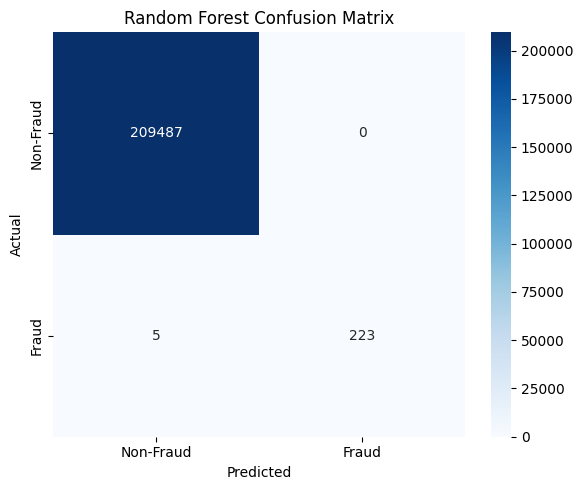

In [36]:
cm = confusion_matrix(
    y_test,
    rf_prediction
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-Fraud",
        "Fraud"
    ],
    yticklabels=[
        "Non-Fraud",
        "Fraud"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**15. FEATURE IMPORTANCE**


TOP FRAUD DETECTION FEATURES
                        Feature  Importance
       remainder__balance_error    0.323018
     remainder__account_drained    0.201643
remainder__amount_balance_ratio    0.149975
 remainder__orig_balance_change    0.125512
      remainder__newbalanceOrig    0.066145
                remainder__step    0.037473
       remainder__oldbalanceOrg    0.017926
 transaction_type__type_PAYMENT    0.016348
              remainder__amount    0.015084
transaction_type__type_TRANSFER    0.011936


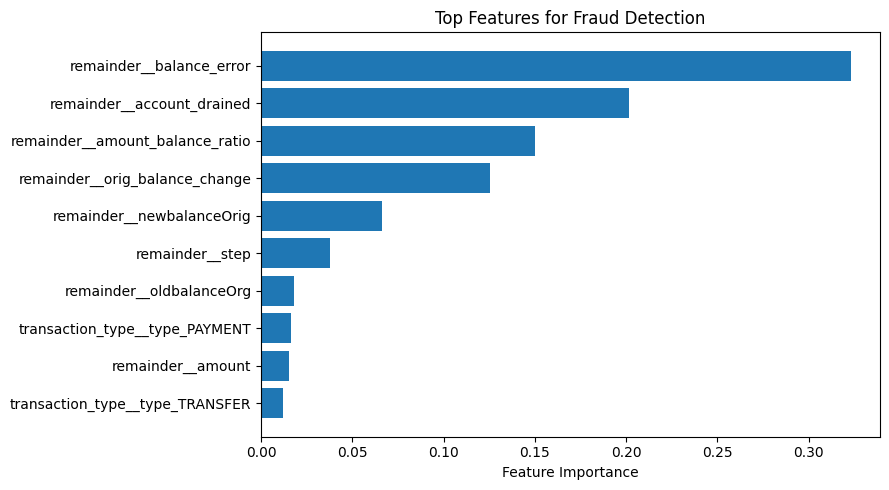

In [37]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)


feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        random_forest.feature_importances_

})


feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


print("\n" + "=" * 60)
print("TOP FRAUD DETECTION FEATURES")
print("=" * 60)

print(
    feature_importance
    .head(10)
    .to_string(index=False)
)

# Visualization

top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)


plt.figure(figsize=(9, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top Features for Fraud Detection"
)

plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

**16. PREDICTION FUNCTION**

In [38]:
def predict_transaction(
    step,
    transaction_type,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,
    isFlaggedFraud=0
):

    # Feature engineering

    orig_balance_change = (
        oldbalanceOrg -
        newbalanceOrig
    )

    dest_balance_change = (
        newbalanceDest -
        oldbalanceDest
    )

    balance_error = abs(
        amount -
        orig_balance_change
    )

    amount_balance_ratio = (
        amount /
        (oldbalanceOrg + 1)
    )

    account_drained = int(
        oldbalanceOrg > 0
        and
        newbalanceOrig == 0
    )
    
    transaction = pd.DataFrame([{

        "step": step,

        "type": transaction_type,

        "amount": amount,

        "oldbalanceOrg":
            oldbalanceOrg,

        "newbalanceOrig":
            newbalanceOrig,

        "oldbalanceDest":
            oldbalanceDest,

        "newbalanceDest":
            newbalanceDest,

        "isFlaggedFraud":
            isFlaggedFraud,

        "orig_balance_change":
            orig_balance_change,

        "dest_balance_change":
            dest_balance_change,

        "balance_error":
            balance_error,
        "amount_balance_ratio":
            amount_balance_ratio,

        "account_drained":
            account_drained
    }])
                

    transaction_processed = (
        preprocessor.transform(
            transaction
        )
    )


    probability = (
        random_forest
        .predict_proba(
            transaction_processed
        )[0, 1]
    )


    prediction = (
        "Fraud"
        if probability >= 0.5
        else "No Fraud"
    )


    return prediction, probability                

**17. TEST A TRANSACTION**

In [39]:
prediction, probability = predict_transaction(

    step=1,

    transaction_type="TRANSFER",

    amount=9000.60,

    oldbalanceOrg=9000.60,

    newbalanceOrig=0,

    oldbalanceDest=0,

    newbalanceDest=0

)


print("\n" + "=" * 60)
print("SAMPLE TRANSACTION PREDICTION")
print("=" * 60)

print("Prediction:", prediction)

print(
    "Fraud Probability:",
    round(probability * 100, 2),
    "%"
)


SAMPLE TRANSACTION PREDICTION
Prediction: Fraud
Fraud Probability: 100.0 %


**CONCLUSION**

In [42]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"Best Model       : {best_model['Model']}")
print(f"Precision        : {best_model['Precision']:.4f}")
print(f"Recall           : {best_model['Recall']:.4f}")
print(f"F1 Score         : {best_model['F1 Score']:.4f}")
print(f"ROC-AUC          : {best_model['ROC-AUC']:.4f}")
print(f"PR-AUC           : {best_model['PR-AUC']:.4f}")

print("\nProject successfully completed.")

PROJECT SUMMARY
Best Model       : Random Forest
Precision        : 1.0000
Recall           : 0.9781
F1 Score         : 0.9889
ROC-AUC          : 0.9964
PR-AUC           : 0.9840

Project successfully completed.
